In [3]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from mpi4py import MPI

from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve

import basix
import ufl
from dolfinx import mesh, fem

try:
    from dolfinx.fem.petsc import LinearProblem
except Exception:
    LinearProblem = None


sns.set_theme(style="whitegrid")

comm = MPI.COMM_WORLD


In [4]:
SOL_KIND = "coscos"
# opções:
# "coscos": p = cos(pi x) cos(pi y)
# "sinsin": p = sin(pi x) sin(pi y)


def p_exact(points, kind=SOL_KIND):
    points = np.asarray(points)
    x = points[:, 0]
    y = points[:, 1]

    if kind == "coscos":
        return np.cos(np.pi * x) * np.cos(np.pi * y)

    if kind == "sinsin":
        return np.sin(np.pi * x) * np.sin(np.pi * y)

    raise ValueError("kind deve ser 'coscos' ou 'sinsin'.")


def u_exact(points, kind=SOL_KIND):
    points = np.asarray(points)
    x = points[:, 0]
    y = points[:, 1]

    if kind == "coscos":
        ux = np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)
        uy = np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)
        return np.column_stack([ux, uy])

    if kind == "sinsin":
        ux = -np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)
        uy = -np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)
        return np.column_stack([ux, uy])

    raise ValueError("kind deve ser 'coscos' ou 'sinsin'.")


def f_exact(points, kind=SOL_KIND):
    points = np.asarray(points)
    return 2.0 * np.pi**2 * p_exact(points, kind=kind)


def p_exact_dolfinx(x, kind=SOL_KIND):
    points = np.column_stack([x[0], x[1]])
    return p_exact(points, kind=kind)


def f_ufl(msh, kind=SOL_KIND):
    x = ufl.SpatialCoordinate(msh)

    if kind == "coscos":
        return 2.0 * np.pi**2 * ufl.cos(np.pi * x[0]) * ufl.cos(np.pi * x[1])

    if kind == "sinsin":
        return 2.0 * np.pi**2 * ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])

    raise ValueError("kind deve ser 'coscos' ou 'sinsin'.")

In [5]:
def create_square_mesh(N):
    msh = mesh.create_unit_square(
        comm,
        N,
        N,
        cell_type=mesh.CellType.triangle
    )

    tdim = msh.topology.dim
    fdim = tdim - 1

    msh.topology.create_connectivity(tdim, 0)
    msh.topology.create_connectivity(tdim, fdim)
    msh.topology.create_connectivity(fdim, 0)
    msh.topology.create_connectivity(fdim, tdim)

    return msh


def get_mesh_data(msh):
    tdim = msh.topology.dim
    fdim = tdim - 1

    coords = msh.geometry.x[:, :2]

    cell_vertices = msh.topology.connectivity(tdim, 0)
    cell_facets = msh.topology.connectivity(tdim, fdim)
    facet_vertices = msh.topology.connectivity(fdim, 0)
    facet_cells = msh.topology.connectivity(fdim, tdim)

    num_cells = msh.topology.index_map(tdim).size_local
    num_facets = msh.topology.index_map(fdim).size_local

    return coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets


def boundary_facets(msh):
    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    bfacets = []
    for f in range(num_facets):
        if len(facet_cells.links(f)) == 1:
            bfacets.append(f)

    return np.array(bfacets, dtype=np.int32)


def cell_diameter(vertices):
    h = 0.0
    for i in range(3):
        for j in range(i + 1, 3):
            h = max(h, np.linalg.norm(vertices[i] - vertices[j]))
    return h


def max_mesh_h(msh):
    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    hmax = 0.0
    for c in range(num_cells):
        vids = cell_vertices.links(c)
        X = coords[vids]
        hmax = max(hmax, cell_diameter(X))

    return hmax


def outward_normal(p0, p1, centroid):
    tangent = p1 - p0
    normal = np.array([tangent[1], -tangent[0]], dtype=float)

    midpoint = 0.5 * (p0 + p1)

    if np.dot(normal, centroid - midpoint) > 0.0:
        normal *= -1.0

    normal /= np.linalg.norm(normal)
    return normal

In [6]:
def basix_topology(cell_type):
    try:
        return basix.topology(cell_type)
    except AttributeError:
        return basix.cell.topology(cell_type)


def create_lagrange_element(cell_type, degree):
    try:
        return basix.create_element(
            basix.ElementFamily.P,
            cell_type,
            degree,
            lagrange_variant=basix.LagrangeVariant.equispaced,
            discontinuous=True
        )
    except TypeError:
        try:
            return basix.create_element(
                basix.ElementFamily.P,
                cell_type,
                degree,
                basix.LagrangeVariant.equispaced,
                basix.DPCVariant.unset,
                True
            )
        except Exception:
            return basix.create_element(
                basix.ElementFamily.P,
                cell_type,
                degree,
                basix.LagrangeVariant.equispaced
            )


def tab_values(tab):
    if tab.ndim == 3:
        return tab[:, :, 0]
    return tab


def reference_data(k, qdeg=None):
    if qdeg is None:
        qdeg = max(2 * k + 8, 12)

    cell_type = basix.CellType.triangle
    edge_type = basix.CellType.interval

    cell_elem = create_lagrange_element(cell_type, k)
    edge_elem = create_lagrange_element(edge_type, k)

    Xq, wq = basix.make_quadrature(cell_type, qdeg)
    T = cell_elem.tabulate(1, Xq)

    phi = tab_values(T[0])
    dphi_dxi = tab_values(T[1])
    dphi_deta = tab_values(T[2])

    tq, w1 = basix.make_quadrature(edge_type, qdeg)
    tq = tq[:, 0]

    edge_points = edge_elem.points[:, 0]
    n_edge = edge_elem.dim

    ref_vertices = np.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.0, 1.0]
    ])

    ref_edges = basix_topology(cell_type)[1]

    return {
        "cell_elem": cell_elem,
        "edge_elem": edge_elem,
        "Xq": Xq,
        "wq": wq,
        "phi": phi,
        "dphi_dxi": dphi_dxi,
        "dphi_deta": dphi_deta,
        "tq": tq,
        "w1": w1,
        "edge_points": edge_points,
        "n_phi": cell_elem.dim,
        "n_edge": n_edge,
        "ref_vertices": ref_vertices,
        "ref_edges": ref_edges,
        "qdeg": qdeg
    }


def beta_value(beta0, k, hK, beta_scale="k2_over_h"):
    if beta0 == 0.0:
        return 0.0

    if beta_scale == "k2_over_h":
        return beta0 * k**2 / hK

    if beta_scale == "one_over_h":
        return beta0 / hK

    if beta_scale == "constant":
        return beta0

    raise ValueError("beta_scale deve ser 'k2_over_h', 'one_over_h' ou 'constant'.")

In [7]:
def local_lambda_dofs(cell_facet_ids, k, n_edge):
    dofs = []
    for f in cell_facet_ids:
        base = f * n_edge
        dofs.extend([base + i for i in range(n_edge)])
    return np.array(dofs, dtype=np.int64)


def local_matrices_2d(
    msh,
    cell_id,
    k,
    beta,
    delta1=0.0,
    delta2=0.0,
    delta3=0.0,
    kind=SOL_KIND,
    ref=None
):
    if ref is None:
        ref = reference_data(k)

    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    vids = cell_vertices.links(cell_id)
    fids = cell_facets.links(cell_id)

    Xv = coords[vids]
    centroid = Xv.mean(axis=0)

    J = np.column_stack([Xv[1] - Xv[0], Xv[2] - Xv[0]])
    detJ = abs(np.linalg.det(J))
    invJ = np.linalg.inv(J)

    Xq = ref["Xq"]
    wq = ref["wq"]
    phi = ref["phi"]
    dphi_ref = np.stack([ref["dphi_dxi"], ref["dphi_deta"]], axis=2)

    grad_phi = np.einsum("qia,ab->qib", dphi_ref, invJ)

    gx = grad_phi[:, :, 0]
    gy = grad_phi[:, :, 1]

    x_phys = Xv[0] + Xq @ J.T
    fval = f_exact(x_phys, kind=kind)

    W = wq * detJ

    n_phi = ref["n_phi"]
    n_edge = ref["n_edge"]

    n_u = 2 * n_phi
    n_local = 3 * n_phi
    n_lambda_local = 3 * n_edge

    sx = slice(0, n_phi)
    sy = slice(n_phi, 2 * n_phi)
    sp = slice(2 * n_phi, 3 * n_phi)

    A = np.zeros((n_local, n_local))
    B = np.zeros((n_local, n_lambda_local))
    C = np.zeros((n_lambda_local, n_lambda_local))
    F = np.zeros(n_local)

    M = phi.T @ (W[:, None] * phi)

    Dx_trial = phi.T @ (W[:, None] * gx)
    Dy_trial = phi.T @ (W[:, None] * gy)

    Dx_test = gx.T @ (W[:, None] * phi)
    Dy_test = gy.T @ (W[:, None] * phi)

    Kxx = gx.T @ (W[:, None] * gx)
    Kxy = gx.T @ (W[:, None] * gy)
    Kyx = gy.T @ (W[:, None] * gx)
    Kyy = gy.T @ (W[:, None] * gy)

    Kgrad = Kxx + Kyy

    # Termos principais
    A[sx, sx] += M
    A[sy, sy] += M

    A[sx, sp] += -Dx_test
    A[sy, sp] += -Dy_test

    A[sp, sx] += -Dx_trial
    A[sp, sy] += -Dy_trial

    F[sp] += -(phi.T @ (W * fval))

    # Estabilização constitutiva: delta1 * int (u + grad p).(v + grad q)
    if delta1 != 0.0:
        A[sx, sx] += delta1 * M
        A[sy, sy] += delta1 * M

        A[sx, sp] += delta1 * Dx_trial
        A[sy, sp] += delta1 * Dy_trial

        A[sp, sx] += delta1 * Dx_test
        A[sp, sy] += delta1 * Dy_test

        A[sp, sp] += delta1 * Kgrad

    # Estabilização de divergência: delta2 * int div(u) div(v)
    if delta2 != 0.0:
        A[sx, sx] += delta2 * Kxx
        A[sx, sy] += delta2 * Kxy
        A[sy, sx] += delta2 * Kyx
        A[sy, sy] += delta2 * Kyy

        F[sx] += delta2 * (gx.T @ (W * fval))
        F[sy] += delta2 * (gy.T @ (W * fval))

    # Estabilização rotacional em 2D:
    # curl u = d uy / dx - d ux / dy
    if delta3 != 0.0:
        A[sx, sx] += delta3 * Kyy
        A[sx, sy] += -delta3 * Kyx
        A[sy, sx] += -delta3 * Kxy
        A[sy, sy] += delta3 * Kxx

    # Termos de faceta
    tq = ref["tq"]
    w1 = ref["w1"]
    edge_elem = ref["edge_elem"]
    ref_vertices = ref["ref_vertices"]
    ref_edges = ref["ref_edges"]

    for local_facet_id, edge_vertices_ref in enumerate(ref_edges):
        lv0, lv1 = edge_vertices_ref

        gv0 = vids[lv0]
        gv1 = vids[lv1]

        p0 = Xv[lv0]
        p1 = Xv[lv1]

        edge_length = np.linalg.norm(p1 - p0)
        normal = outward_normal(p0, p1, centroid)

        Xref_edge = ref_vertices[lv0] + tq[:, None] * (ref_vertices[lv1] - ref_vertices[lv0])
        phi_edge = tab_values(ref["cell_elem"].tabulate(0, Xref_edge)[0])

        same_orientation = gv0 < gv1
        s_global = tq if same_orientation else 1.0 - tq
        lambda_edge = tab_values(edge_elem.tabulate(0, s_global.reshape(-1, 1))[0])

        Wedge = w1 * edge_length

        E = phi_edge.T @ (Wedge[:, None] * lambda_edge)
        Mlam = lambda_edge.T @ (Wedge[:, None] * lambda_edge)

        col0 = local_facet_id * n_edge
        col1 = (local_facet_id + 1) * n_edge
        sl = slice(col0, col1)

        A[sp, sp] += beta * (phi_edge.T @ (Wedge[:, None] * phi_edge))

        B[sx, sl] += normal[0] * E
        B[sy, sl] += normal[1] * E
        B[sp, sl] += -beta * E

        C[sl, sl] += beta * Mlam

    return A, B, C, F

In [8]:
def exact_lambda_coeffs(msh, k, kind=SOL_KIND):
    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    ref = reference_data(k)
    edge_points = ref["edge_points"]
    n_edge = ref["n_edge"]

    lam = np.zeros(num_facets * n_edge)

    for f in range(num_facets):
        vids = facet_vertices.links(f)

        v0 = min(vids)
        v1 = max(vids)

        p0 = coords[v0]
        p1 = coords[v1]

        points = p0 + edge_points[:, None] * (p1 - p0)
        values = p_exact(points, kind=kind)

        lam[f * n_edge:(f + 1) * n_edge] = values

    return lam


def lambda_fixed_mask(msh, k):
    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    ref = reference_data(k)
    n_edge = ref["n_edge"]

    fixed = np.zeros(num_facets * n_edge, dtype=bool)

    for f in boundary_facets(msh):
        fixed[f * n_edge:(f + 1) * n_edge] = True

    return fixed

In [9]:
def solve_known_lambda_2d(
    N=None,
    k=1,
    beta0=10.0,
    beta_scale="k2_over_h",
    delta1=0.0,
    delta2=0.0,
    delta3=0.0,
    kind=SOL_KIND,
    msh=None,
    lambda_coeffs=None
):
    if msh is None:
        msh = create_square_mesh(N)

    ref = reference_data(k)

    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    if lambda_coeffs is None:
        lambda_coeffs = exact_lambda_coeffs(msh, k, kind=kind)

    solutions = []
    conds = []
    betas = []

    for cell_id in range(num_cells):
        vids = cell_vertices.links(cell_id)
        fids = cell_facets.links(cell_id)

        Xv = coords[vids]
        hK = cell_diameter(Xv)
        beta = beta_value(beta0, k, hK, beta_scale=beta_scale)

        A, B, C, F = local_matrices_2d(
            msh,
            cell_id,
            k,
            beta,
            delta1=delta1,
            delta2=delta2,
            delta3=delta3,
            kind=kind,
            ref=ref
        )

        ldofs = local_lambda_dofs(fids, k, ref["n_edge"])
        lam_loc = lambda_coeffs[ldofs]

        rhs = F - B @ lam_loc

        conds.append(np.linalg.cond(A))
        betas.append(beta)

        try:
            U = np.linalg.solve(A, rhs)
        except np.linalg.LinAlgError:
            print(f"Matriz local singular no elemento {cell_id}. Usando mínimos quadrados.")
            U = np.linalg.lstsq(A, rhs, rcond=None)[0]

        solutions.append(U)

    return {
        "msh": msh,
        "k": k,
        "kind": kind,
        "solutions": solutions,
        "lambda_coeffs": lambda_coeffs,
        "beta_max": max(betas) if len(betas) > 0 else 0.0,
        "beta_min": min(betas) if len(betas) > 0 else 0.0,
        "cond_max": max(conds) if len(conds) > 0 else np.nan,
        "h": max_mesh_h(msh),
        "solver": "known_lambda",
        "params": {
            "beta0": beta0,
            "beta_scale": beta_scale,
            "delta1": delta1,
            "delta2": delta2,
            "delta3": delta3
        }
    }

In [10]:
def solve_hybrid_unknown_2d(
    N=None,
    k=1,
    beta0=10.0,
    beta_scale="k2_over_h",
    delta1=0.0,
    delta2=0.0,
    delta3=0.0,
    kind=SOL_KIND,
    msh=None
):
    if msh is None:
        msh = create_square_mesh(N)

    ref = reference_data(k)

    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    n_edge = ref["n_edge"]
    n_lambda_total = num_facets * n_edge

    lambda_full = np.zeros(n_lambda_total)
    lambda_exact = exact_lambda_coeffs(msh, k, kind=kind)

    fixed = lambda_fixed_mask(msh, k)
    free = ~fixed

    lambda_full[fixed] = lambda_exact[fixed]

    free_number = -np.ones(n_lambda_total, dtype=np.int64)
    free_number[free] = np.arange(np.count_nonzero(free))

    rows = []
    cols = []
    vals = []
    rhs_global = np.zeros(np.count_nonzero(free))

    local_data = []
    conds = []
    betas = []

    for cell_id in range(num_cells):
        vids = cell_vertices.links(cell_id)
        fids = cell_facets.links(cell_id)

        Xv = coords[vids]
        hK = cell_diameter(Xv)
        beta = beta_value(beta0, k, hK, beta_scale=beta_scale)

        A, B, C, F = local_matrices_2d(
            msh,
            cell_id,
            k,
            beta,
            delta1=delta1,
            delta2=delta2,
            delta3=delta3,
            kind=kind,
            ref=ref
        )

        conds.append(np.linalg.cond(A))
        betas.append(beta)

        AinvB = np.linalg.solve(A, B)
        AinvF = np.linalg.solve(A, F)

        S_loc = B.T @ AinvB - C
        rhs_loc = B.T @ AinvF

        ldofs = local_lambda_dofs(fids, k, n_edge)

        for i_local, i_global in enumerate(ldofs):
            if free[i_global]:
                ii = free_number[i_global]
                rhs_global[ii] += rhs_loc[i_local]

                for j_local, j_global in enumerate(ldofs):
                    if free[j_global]:
                        jj = free_number[j_global]
                        rows.append(ii)
                        cols.append(jj)
                        vals.append(S_loc[i_local, j_local])
                    else:
                        rhs_global[ii] -= S_loc[i_local, j_local] * lambda_full[j_global]

        local_data.append({
            "cell_id": cell_id,
            "AinvB": AinvB,
            "AinvF": AinvF,
            "ldofs": ldofs
        })

    if np.count_nonzero(free) > 0:
        K_global = coo_matrix(
            (vals, (rows, cols)),
            shape=(np.count_nonzero(free), np.count_nonzero(free))
        ).tocsr()

        lambda_free = spsolve(K_global, rhs_global)
        lambda_full[free] = lambda_free
    else:
        K_global = None

    solutions = []

    for data in local_data:
        lam_loc = lambda_full[data["ldofs"]]
        U = data["AinvF"] - data["AinvB"] @ lam_loc
        solutions.append(U)

    return {
        "msh": msh,
        "k": k,
        "kind": kind,
        "solutions": solutions,
        "lambda_coeffs": lambda_full,
        "lambda_exact": lambda_exact,
        "fixed_lambda": fixed,
        "free_lambda": free,
        "K_lambda": K_global,
        "beta_max": max(betas) if len(betas) > 0 else 0.0,
        "beta_min": min(betas) if len(betas) > 0 else 0.0,
        "cond_max": max(conds) if len(conds) > 0 else np.nan,
        "h": max_mesh_h(msh),
        "solver": "hybrid_unknown_lambda",
        "params": {
            "beta0": beta0,
            "beta_scale": beta_scale,
            "delta1": delta1,
            "delta2": delta2,
            "delta3": delta3
        }
    }

In [11]:
def compute_L2_errors(result):
    msh = result["msh"]
    k = result["k"]
    kind = result["kind"]
    solutions = result["solutions"]

    ref = reference_data(k, qdeg=max(2 * k + 12, 16))

    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    Xq = ref["Xq"]
    wq = ref["wq"]
    phi = ref["phi"]

    n_phi = ref["n_phi"]

    err_u2 = 0.0
    err_p2 = 0.0

    for cell_id in range(num_cells):
        vids = cell_vertices.links(cell_id)
        Xv = coords[vids]

        J = np.column_stack([Xv[1] - Xv[0], Xv[2] - Xv[0]])
        detJ = abs(np.linalg.det(J))

        x_phys = Xv[0] + Xq @ J.T
        W = wq * detJ

        U = solutions[cell_id]

        uh_x = phi @ U[0:n_phi]
        uh_y = phi @ U[n_phi:2 * n_phi]
        ph = phi @ U[2 * n_phi:3 * n_phi]

        ue = u_exact(x_phys, kind=kind)
        pe = p_exact(x_phys, kind=kind)

        err_u2 += np.sum(W * ((uh_x - ue[:, 0])**2 + (uh_y - ue[:, 1])**2))
        err_p2 += np.sum(W * (ph - pe)**2)

    return np.sqrt(err_u2), np.sqrt(err_p2)


def compute_lambda_skeleton_error(result):
    msh = result["msh"]
    k = result["k"]
    kind = result["kind"]
    lambda_coeffs = result["lambda_coeffs"]

    ref = reference_data(k, qdeg=max(2 * k + 10, 14))

    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    edge_elem = ref["edge_elem"]
    tq = ref["tq"]
    w1 = ref["w1"]
    n_edge = ref["n_edge"]

    err2 = 0.0

    for f in range(num_facets):
        vids = facet_vertices.links(f)

        v0 = min(vids)
        v1 = max(vids)

        p0 = coords[v0]
        p1 = coords[v1]

        length = np.linalg.norm(p1 - p0)

        points = p0 + tq[:, None] * (p1 - p0)

        lvals = tab_values(edge_elem.tabulate(0, tq.reshape(-1, 1))[0])
        lam_h = lvals @ lambda_coeffs[f * n_edge:(f + 1) * n_edge]

        lam_e = p_exact(points, kind=kind)

        err2 += np.sum(w1 * length * (lam_h - lam_e)**2)

    return np.sqrt(err2)

In [12]:
N = 8
k = 1

res_known = solve_known_lambda_2d(
    N=N,
    k=k,
    beta0=10.0,
    beta_scale="k2_over_h",
    delta1=0.0,
    delta2=0.0,
    delta3=0.0,
    kind=SOL_KIND
)

err_u, err_p = compute_L2_errors(res_known)

print("λ conhecido, penalização beta")
print(f"N = {N}, k = {k}")
print(f"h       = {res_known['h']:.4e}")
print(f"beta max= {res_known['beta_max']:.4e}")
print(f"erro u  = {err_u:.4e}")
print(f"erro p  = {err_p:.4e}")
print(f"cond max= {res_known['cond_max']:.4e}")

λ conhecido, penalização beta
N = 8, k = 1
h       = 1.7678e-01
beta max= 5.6569e+01
erro u  = 1.9706e+01
erro p  = 3.4763e-01
cond max= 1.3990e+06


In [13]:
N = 8
k = 1

res_hybrid = solve_hybrid_unknown_2d(
    N=N,
    k=k,
    beta0=10.0,
    beta_scale="k2_over_h",
    delta1=0.0,
    delta2=0.0,
    delta3=0.0,
    kind=SOL_KIND
)

err_u, err_p = compute_L2_errors(res_hybrid)
err_lam = compute_lambda_skeleton_error(res_hybrid)

print("λ incógnita, formulação híbrida com condensação estática")
print(f"N = {N}, k = {k}")
print(f"h        = {res_hybrid['h']:.4e}")
print(f"beta max = {res_hybrid['beta_max']:.4e}")
print(f"erro u   = {err_u:.4e}")
print(f"erro p   = {err_p:.4e}")
print(f"erro λ   = {err_lam:.4e}")
print(f"cond max = {res_hybrid['cond_max']:.4e}")
print(f"n λ livre= {np.count_nonzero(res_hybrid['free_lambda'])}")

λ incógnita, formulação híbrida com condensação estática
N = 8, k = 1
h        = 1.7678e-01
beta max = 5.6569e+01
erro u   = 4.6858e+00
erro p   = 1.3712e-01
erro λ   = 4.1404e-01
cond max = 1.3990e+06
n λ livre= 352


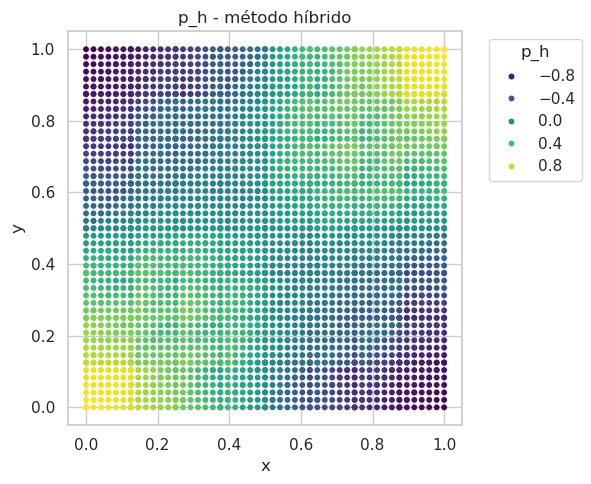

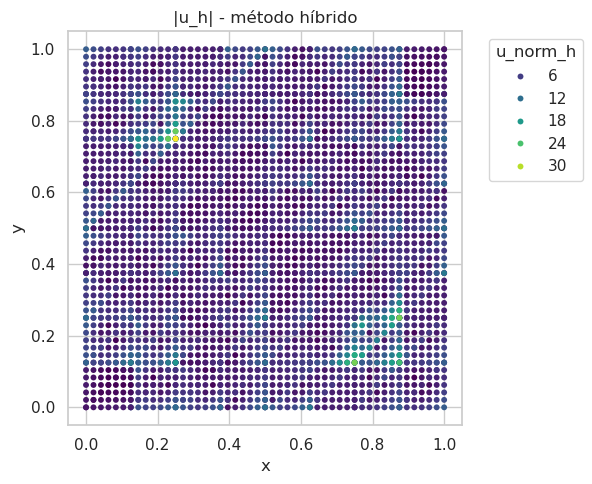

In [14]:
def sample_solution_dataframe(result, m=5):
    msh = result["msh"]
    k = result["k"]
    kind = result["kind"]
    solutions = result["solutions"]

    ref = reference_data(k)

    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    pts = []
    for i in range(m + 1):
        for j in range(m + 1 - i):
            xi = i / m
            eta = j / m
            pts.append([xi, eta])

    pts = np.array(pts)

    phi = tab_values(ref["cell_elem"].tabulate(0, pts)[0])
    n_phi = ref["n_phi"]

    rows = []

    for cell_id in range(num_cells):
        vids = cell_vertices.links(cell_id)
        Xv = coords[vids]

        J = np.column_stack([Xv[1] - Xv[0], Xv[2] - Xv[0]])
        x_phys = Xv[0] + pts @ J.T

        U = solutions[cell_id]

        uh_x = phi @ U[0:n_phi]
        uh_y = phi @ U[n_phi:2 * n_phi]
        ph = phi @ U[2 * n_phi:3 * n_phi]

        pe = p_exact(x_phys, kind=kind)
        ue = u_exact(x_phys, kind=kind)

        for a in range(len(pts)):
            rows.append({
                "cell": cell_id,
                "x": x_phys[a, 0],
                "y": x_phys[a, 1],
                "p_h": ph[a],
                "p_exact": pe[a],
                "u_x_h": uh_x[a],
                "u_y_h": uh_y[a],
                "u_norm_h": np.sqrt(uh_x[a]**2 + uh_y[a]**2),
                "u_x_exact": ue[a, 0],
                "u_y_exact": ue[a, 1],
                "u_norm_exact": np.sqrt(ue[a, 0]**2 + ue[a, 1]**2),
            })

    return pd.DataFrame(rows)


def plot_field(df, value, title=None):
    plt.figure(figsize=(6, 5))
    ax = sns.scatterplot(
        data=df,
        x="x",
        y="y",
        hue=value,
        s=18,
        linewidth=0,
        palette="viridis"
    )
    ax.set_aspect("equal")
    ax.set_title(title if title is not None else value)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.legend(title=value, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


df_plot = sample_solution_dataframe(res_hybrid, m=6)

plot_field(df_plot, "p_h", title="p_h - método híbrido")
plot_field(df_plot, "u_norm_h", title="|u_h| - método híbrido")

In [15]:
def convergence_table_2d(
    N_list,
    k_list,
    solver="hybrid",
    case_name="",
    beta0=10.0,
    beta_scale="k2_over_h",
    delta1=0.0,
    delta2=0.0,
    delta3=0.0,
    kind=SOL_KIND
):
    rows = []

    for k in k_list:
        previous_h = None
        previous_err_u = None
        previous_err_p = None
        previous_err_lam = None

        for N in N_list:
            start = time.time()

            if solver == "known":
                result = solve_known_lambda_2d(
                    N=N,
                    k=k,
                    beta0=beta0,
                    beta_scale=beta_scale,
                    delta1=delta1,
                    delta2=delta2,
                    delta3=delta3,
                    kind=kind
                )

            elif solver == "hybrid":
                result = solve_hybrid_unknown_2d(
                    N=N,
                    k=k,
                    beta0=beta0,
                    beta_scale=beta_scale,
                    delta1=delta1,
                    delta2=delta2,
                    delta3=delta3,
                    kind=kind
                )

            else:
                raise ValueError("solver deve ser 'known' ou 'hybrid'.")

            err_u, err_p = compute_L2_errors(result)

            if solver == "hybrid":
                err_lam = compute_lambda_skeleton_error(result)
            else:
                err_lam = np.nan

            elapsed = time.time() - start

            h = result["h"]

            if previous_h is None:
                rate_u = np.nan
                rate_p = np.nan
                rate_lam = np.nan
            else:
                rate_u = np.log(previous_err_u / err_u) / np.log(previous_h / h)
                rate_p = np.log(previous_err_p / err_p) / np.log(previous_h / h)

                if np.isfinite(previous_err_lam) and previous_err_lam > 0 and err_lam > 0:
                    rate_lam = np.log(previous_err_lam / err_lam) / np.log(previous_h / h)
                else:
                    rate_lam = np.nan

            rows.append({
                "case": case_name,
                "solver": solver,
                "N": N,
                "k": k,
                "h": h,
                "beta_max": result["beta_max"],
                "delta1": delta1,
                "delta2": delta2,
                "delta3": delta3,
                "err_u": err_u,
                "rate_u": rate_u,
                "err_p": err_p,
                "rate_p": rate_p,
                "err_lambda": err_lam,
                "rate_lambda": rate_lam,
                "time_s": elapsed,
                "cond_local_max": result["cond_max"]
            })

            previous_h = h
            previous_err_u = err_u
            previous_err_p = err_p
            previous_err_lam = err_lam

            print(
                f"{case_name:28s} | solver={solver:7s} | "
                f"N={N:3d} | k={k} | "
                f"err_u={err_u:.3e} | err_p={err_p:.3e} | "
                f"time={elapsed:.2f}s"
            )

    return pd.DataFrame(rows)

In [16]:
N_list = [4, 8, 16]
k_list = [1, 2, 3, 4, 5]

# Caso 1: penalização beta
tab_beta = convergence_table_2d(
    N_list=N_list,
    k_list=k_list,
    solver="hybrid",
    case_name="beta",
    beta0=10.0,
    beta_scale="k2_over_h",
    delta1=0.0,
    delta2=0.0,
    delta3=0.0,
    kind=SOL_KIND
)

tab_beta

beta                         | solver=hybrid  | N=  4 | k=1 | err_u=1.013e+01 | err_p=5.930e-01 | time=0.02s
beta                         | solver=hybrid  | N=  8 | k=1 | err_u=4.686e+00 | err_p=1.371e-01 | time=0.06s
beta                         | solver=hybrid  | N= 16 | k=1 | err_u=1.520e+00 | err_p=2.448e-02 | time=0.23s
beta                         | solver=hybrid  | N=  4 | k=2 | err_u=4.103e+00 | err_p=1.148e-01 | time=0.02s
beta                         | solver=hybrid  | N=  8 | k=2 | err_u=5.806e-01 | err_p=7.213e-03 | time=0.06s
beta                         | solver=hybrid  | N= 16 | k=2 | err_u=3.887e-01 | err_p=2.429e-03 | time=0.25s
beta                         | solver=hybrid  | N=  4 | k=3 | err_u=5.951e-02 | err_p=1.086e-03 | time=0.02s
beta                         | solver=hybrid  | N=  8 | k=3 | err_u=6.829e-03 | err_p=6.115e-05 | time=0.07s
beta                         | solver=hybrid  | N= 16 | k=3 | err_u=8.786e-04 | err_p=3.818e-06 | time=0.30s
beta               

,case,solver,N,k,h,beta_max,delta1,delta2,delta3,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,time_s,cond_local_max
0,beta,hybrid,4,1,0.353553,28.284271,0.0,0.0,0.0,1.013183e+01,NaN,5.930209e-01,NaN,1.237370e+00,NaN,0.018939,3.499274e+05
1,beta,hybrid,8,1,0.176777,56.568542,0.0,0.0,0.0,4.685846e+00,1.112513,1.371227e-01,2.112616,4.140369e-01,1.579445,0.058225,1.399033e+06
2,beta,hybrid,16,1,0.088388,113.137085,0.0,0.0,0.0,1.519742e+00,1.624483,2.448309e-02,2.485610,9.448470e-02,2.131607,0.226903,5.595453e+06
3,beta,hybrid,4,2,0.353553,113.137085,0.0,0.0,0.0,4.103093e+00,NaN,1.147927e-01,NaN,3.382052e-01,NaN,0.016705,1.899310e+05
4,beta,hybrid,8,2,0.176777,226.274170,0.0,0.0,0.0,5.805696e-01,2.821171,7.212991e-03,3.992289,3.260515e-02,3.374727,0.062255,7.595505e+05
5,beta,hybrid,16,2,0.088388,452.548340,0.0,0.0,0.0,3.887440e-01,0.578649,2.428803e-03,1.570352,1.641932e-02,0.989705,0.252443,3.038028e+06
6,beta,hybrid,4,3,0.353553,254.558441,0.0,0.0,0.0,5.950940e-02,NaN,1.085826e-03,NaN,5.539665e-03,NaN,0.018998,1.814011e+05
7,beta,hybrid,8,3,0.176777,509.116882,0.0,0.0,0.0,6.828897e-03,3.123393,6.115238e-05,4.150240,4.061754e-04,3.769624,0.071877,7.255974e+05
8,beta,hybrid,16,3,0.088388,1018.233765,0.0,0.0,0.0,8.785905e-04,2.958390,3.817722e-06,4.001625,3.571719e-05,3.507412,0.302049,2.902383e+06
9,beta,hybrid,4,4,0.353553,452.548340,0.0,0.0,0.0,2.346989e-03,NaN,3.743895e-05,NaN,2.316561e-04,NaN,0.023773,6.705760e+05


In [17]:
# Caso 2: estabilização constitutiva, beta = 0
tab_delta1 = convergence_table_2d(
    N_list=N_list,
    k_list=k_list,
    solver="hybrid",
    case_name="delta1",
    beta0=0.0,
    beta_scale="constant",
    delta1=-0.5,
    delta2=0.0,
    delta3=0.0,
    kind=SOL_KIND
)

tab_delta1


delta1                       | solver=hybrid  | N=  4 | k=1 | err_u=3.760e-01 | err_p=3.845e-02 | time=0.02s
delta1                       | solver=hybrid  | N=  8 | k=1 | err_u=1.545e-01 | err_p=1.009e-02 | time=0.06s
delta1                       | solver=hybrid  | N= 16 | k=1 | err_u=7.217e-02 | err_p=2.558e-03 | time=0.23s
delta1                       | solver=hybrid  | N=  4 | k=2 | err_u=5.112e-02 | err_p=2.691e-03 | time=0.02s
delta1                       | solver=hybrid  | N=  8 | k=2 | err_u=1.140e-02 | err_p=3.283e-04 | time=0.07s
delta1                       | solver=hybrid  | N= 16 | k=2 | err_u=2.644e-03 | err_p=4.054e-05 | time=0.27s
delta1                       | solver=hybrid  | N=  4 | k=3 | err_u=4.536e-03 | err_p=2.421e-04 | time=0.02s
delta1                       | solver=hybrid  | N=  8 | k=3 | err_u=5.218e-04 | err_p=1.509e-05 | time=0.08s
delta1                       | solver=hybrid  | N= 16 | k=3 | err_u=6.215e-05 | err_p=9.382e-07 | time=0.31s
delta1             

,case,solver,N,k,h,beta_max,delta1,delta2,delta3,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,time_s,cond_local_max
0,delta1,hybrid,4,1,0.353553,0.0,-0.5,0.0,0.0,3.759688e-01,NaN,3.845425e-02,NaN,1.433439e-01,NaN,0.018497,5.799456e+02
1,delta1,hybrid,8,1,0.176777,0.0,-0.5,0.0,0.0,1.544502e-01,1.283472,1.008738e-02,1.930591,5.025408e-02,1.512168,0.061219,2.307986e+03
2,delta1,hybrid,16,1,0.088388,0.0,-0.5,0.0,0.0,7.216833e-02,1.097704,2.558167e-03,1.979370,1.758475e-02,1.514916,0.228362,9.219997e+03
3,delta1,hybrid,4,2,0.353553,0.0,-0.5,0.0,0.0,5.111748e-02,NaN,2.690549e-03,NaN,1.186886e-02,NaN,0.017345,6.750092e+03
4,delta1,hybrid,8,2,0.176777,0.0,-0.5,0.0,0.0,1.140137e-02,2.164610,3.283392e-04,3.034641,2.031687e-03,2.546431,0.069185,2.697338e+04
5,delta1,hybrid,16,2,0.088388,0.0,-0.5,0.0,0.0,2.643844e-03,2.108498,4.053945e-05,3.017789,3.517944e-04,2.529874,0.265280,1.078665e+05
6,delta1,hybrid,4,3,0.353553,0.0,-0.5,0.0,0.0,4.536159e-03,NaN,2.421215e-04,NaN,1.120308e-03,NaN,0.021201,3.608520e+04
7,delta1,hybrid,8,3,0.176777,0.0,-0.5,0.0,0.0,5.218474e-04,3.119772,1.509052e-05,4.004017,9.942828e-05,3.494096,0.078056,1.443306e+05
8,delta1,hybrid,16,3,0.088388,0.0,-0.5,0.0,0.0,6.215345e-05,3.069721,9.382077e-07,4.007591,8.751979e-06,3.505975,0.314447,5.773121e+05
9,delta1,hybrid,4,4,0.353553,0.0,-0.5,0.0,0.0,4.327822e-04,NaN,1.805745e-05,NaN,8.711422e-05,NaN,0.024260,1.448020e+05


In [18]:
# Caso 3: estabilização constitutiva + divergência, beta = 0
tab_delta1_delta2 = convergence_table_2d(
    N_list=N_list,
    k_list=k_list,
    solver="hybrid",
    case_name="delta1_delta2",
    beta0=0.0,
    beta_scale="constant",
    delta1=-0.5,
    delta2=0.5,
    delta3=0.0,
    kind=SOL_KIND
)

tab_delta1_delta2

delta1_delta2                | solver=hybrid  | N=  4 | k=1 | err_u=3.760e-01 | err_p=3.845e-02 | time=0.02s
delta1_delta2                | solver=hybrid  | N=  8 | k=1 | err_u=1.545e-01 | err_p=1.009e-02 | time=0.07s
delta1_delta2                | solver=hybrid  | N= 16 | k=1 | err_u=7.217e-02 | err_p=2.558e-03 | time=0.25s
delta1_delta2                | solver=hybrid  | N=  4 | k=2 | err_u=4.784e-02 | err_p=3.197e-03 | time=0.02s
delta1_delta2                | solver=hybrid  | N=  8 | k=2 | err_u=1.053e-02 | err_p=3.911e-04 | time=0.07s
delta1_delta2                | solver=hybrid  | N= 16 | k=2 | err_u=2.419e-03 | err_p=4.827e-05 | time=0.30s
delta1_delta2                | solver=hybrid  | N=  4 | k=3 | err_u=3.296e-03 | err_p=2.986e-04 | time=0.02s
delta1_delta2                | solver=hybrid  | N=  8 | k=3 | err_u=3.567e-04 | err_p=1.851e-05 | time=0.08s
delta1_delta2                | solver=hybrid  | N= 16 | k=3 | err_u=4.102e-05 | err_p=1.147e-06 | time=0.35s
delta1_delta2      

,case,solver,N,k,h,beta_max,delta1,delta2,delta3,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,time_s,cond_local_max
0,delta1_delta2,hybrid,4,1,0.353553,0.0,-0.5,0.5,0.0,3.759688e-01,NaN,3.845425e-02,NaN,1.433439e-01,NaN,0.019848,7.846603e+02
1,delta1_delta2,hybrid,8,1,0.176777,0.0,-0.5,0.5,0.0,1.544502e-01,1.283472,1.008738e-02,1.930591,5.025408e-02,1.512168,0.066215,3.088912e+03
2,delta1_delta2,hybrid,16,1,0.088388,0.0,-0.5,0.5,0.0,7.216833e-02,1.097704,2.558167e-03,1.979370,1.758475e-02,1.514916,0.253845,1.230498e+04
3,delta1_delta2,hybrid,4,2,0.353553,0.0,-0.5,0.5,0.0,4.783820e-02,NaN,3.197279e-03,NaN,1.184771e-02,NaN,0.019070,6.715525e+03
4,delta1_delta2,hybrid,8,2,0.176777,0.0,-0.5,0.5,0.0,1.052581e-02,2.184232,3.910614e-04,3.031378,2.028613e-03,2.546043,0.074015,2.676406e+04
5,delta1_delta2,hybrid,16,2,0.088388,0.0,-0.5,0.5,0.0,2.418570e-03,2.121705,4.826902e-05,3.018226,3.513208e-04,2.529633,0.303560,1.069580e+05
6,delta1_delta2,hybrid,4,3,0.353553,0.0,-0.5,0.5,0.0,3.296393e-03,NaN,2.985919e-04,NaN,1.107016e-03,NaN,0.022074,3.529933e+04
7,delta1_delta2,hybrid,8,3,0.176777,0.0,-0.5,0.5,0.0,3.566727e-04,3.208215,1.850704e-05,4.012029,9.832597e-05,3.492960,0.083317,1.411845e+05
8,delta1_delta2,hybrid,16,3,0.088388,0.0,-0.5,0.5,0.0,4.102349e-05,3.120079,1.147019e-06,4.012113,8.659112e-06,3.505282,0.354651,5.647254e+05
9,delta1_delta2,hybrid,4,4,0.353553,0.0,-0.5,0.5,0.0,2.229151e-04,NaN,2.205551e-05,NaN,8.543325e-05,NaN,0.025625,1.416542e+05


In [19]:
# Caso 4: constitutiva + divergência + rotacional, beta = 0
tab_delta1_delta2_delta3 = convergence_table_2d(
    N_list=N_list,
    k_list=k_list,
    solver="hybrid",
    case_name="delta1_delta2_delta3",
    beta0=0.0,
    beta_scale="constant",
    delta1=-0.5,
    delta2=0.5,
    delta3=0.5,
    kind=SOL_KIND
)

tab_delta1_delta2_delta3

delta1_delta2_delta3         | solver=hybrid  | N=  4 | k=1 | err_u=3.978e-01 | err_p=3.565e-02 | time=0.02s
delta1_delta2_delta3         | solver=hybrid  | N=  8 | k=1 | err_u=1.715e-01 | err_p=8.914e-03 | time=0.07s
delta1_delta2_delta3         | solver=hybrid  | N= 16 | k=1 | err_u=8.194e-02 | err_p=2.224e-03 | time=0.25s
delta1_delta2_delta3         | solver=hybrid  | N=  4 | k=2 | err_u=9.846e-02 | err_p=4.520e-03 | time=0.02s
delta1_delta2_delta3         | solver=hybrid  | N=  8 | k=2 | err_u=2.591e-02 | err_p=6.507e-04 | time=0.07s
delta1_delta2_delta3         | solver=hybrid  | N= 16 | k=2 | err_u=6.609e-03 | err_p=8.373e-05 | time=0.29s
delta1_delta2_delta3         | solver=hybrid  | N=  4 | k=3 | err_u=4.009e-03 | err_p=3.097e-04 | time=0.02s
delta1_delta2_delta3         | solver=hybrid  | N=  8 | k=3 | err_u=5.439e-04 | err_p=1.934e-05 | time=0.09s
delta1_delta2_delta3         | solver=hybrid  | N= 16 | k=3 | err_u=7.473e-05 | err_p=1.208e-06 | time=0.33s
delta1_delta2_delta

,case,solver,N,k,h,beta_max,delta1,delta2,delta3,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,time_s,cond_local_max
0,delta1_delta2_delta3,hybrid,4,1,0.353553,0.0,-0.5,0.5,0.5,3.977680e-01,NaN,3.564774e-02,NaN,1.879036e-01,NaN,0.019107,7.846603e+02
1,delta1_delta2_delta3,hybrid,8,1,0.176777,0.0,-0.5,0.5,0.5,1.714999e-01,1.213719,8.913953e-03,1.999673,1.138933e-01,0.722310,0.065948,3.088912e+03
2,delta1_delta2_delta3,hybrid,16,1,0.088388,0.0,-0.5,0.5,0.5,8.193631e-02,1.065633,2.224482e-03,2.002596,7.738820e-02,0.557498,0.249029,1.230498e+04
3,delta1_delta2_delta3,hybrid,4,2,0.353553,0.0,-0.5,0.5,0.5,9.845672e-02,NaN,4.520068e-03,NaN,1.513545e-01,NaN,0.018401,5.415160e+03
4,delta1_delta2_delta3,hybrid,8,2,0.176777,0.0,-0.5,0.5,0.5,2.590693e-02,1.926152,6.507092e-04,2.796260,6.578045e-02,1.202201,0.068429,2.160348e+04
5,delta1_delta2_delta3,hybrid,16,2,0.088388,0.0,-0.5,0.5,0.5,6.608750e-03,1.970888,8.373091e-05,2.958181,2.546959e-02,1.368883,0.293297,8.635682e+04
6,delta1_delta2_delta3,hybrid,4,3,0.353553,0.0,-0.5,0.5,0.5,4.008691e-03,NaN,3.097286e-04,NaN,7.779634e-02,NaN,0.023190,1.913631e+04
7,delta1_delta2_delta3,hybrid,8,3,0.176777,0.0,-0.5,0.5,0.5,5.438521e-04,2.881845,1.934088e-05,4.001279,1.518938e-02,2.356640,0.087572,7.648417e+04
8,delta1_delta2_delta3,hybrid,16,3,0.088388,0.0,-0.5,0.5,0.5,7.473063e-05,2.863443,1.208191e-06,4.000733,2.765060e-03,2.457680,0.332026,3.058756e+05
9,delta1_delta2_delta3,hybrid,4,4,0.353553,0.0,-0.5,0.5,0.5,3.262162e-04,NaN,2.549422e-05,NaN,4.679227e-03,NaN,0.026409,5.464799e+04


In [20]:
tabs = [
    tab_beta,
    tab_delta1,
    tab_delta1_delta2,
    tab_delta1_delta2_delta3
]

tab_all = pd.concat(tabs, ignore_index=True)

tab_all

,case,solver,N,k,h,beta_max,delta1,delta2,delta3,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,time_s,cond_local_max
0,beta,hybrid,4,1,0.353553,28.284271,0.0,0.0,0.0,1.013183e+01,NaN,5.930209e-01,NaN,1.237370e+00,NaN,0.018939,3.499274e+05
1,beta,hybrid,8,1,0.176777,56.568542,0.0,0.0,0.0,4.685846e+00,1.112513,1.371227e-01,2.112616,4.140369e-01,1.579445,0.058225,1.399033e+06
2,beta,hybrid,16,1,0.088388,113.137085,0.0,0.0,0.0,1.519742e+00,1.624483,2.448309e-02,2.485610,9.448470e-02,2.131607,0.226903,5.595453e+06
3,beta,hybrid,4,2,0.353553,113.137085,0.0,0.0,0.0,4.103093e+00,NaN,1.147927e-01,NaN,3.382052e-01,NaN,0.016705,1.899310e+05
4,beta,hybrid,8,2,0.176777,226.274170,0.0,0.0,0.0,5.805696e-01,2.821171,7.212991e-03,3.992289,3.260515e-02,3.374727,0.062255,7.595505e+05
5,beta,hybrid,16,2,0.088388,452.548340,0.0,0.0,0.0,3.887440e-01,0.578649,2.428803e-03,1.570352,1.641932e-02,0.989705,0.252443,3.038028e+06
6,beta,hybrid,4,3,0.353553,254.558441,0.0,0.0,0.0,5.950940e-02,NaN,1.085826e-03,NaN,5.539665e-03,NaN,0.018998,1.814011e+05
7,beta,hybrid,8,3,0.176777,509.116882,0.0,0.0,0.0,6.828897e-03,3.123393,6.115238e-05,4.150240,4.061754e-04,3.769624,0.071877,7.255974e+05
8,beta,hybrid,16,3,0.088388,1018.233765,0.0,0.0,0.0,8.785905e-04,2.958390,3.817722e-06,4.001625,3.571719e-05,3.507412,0.302049,2.902383e+06
9,beta,hybrid,4,4,0.353553,452.548340,0.0,0.0,0.0,2.346989e-03,NaN,3.743895e-05,NaN,2.316561e-04,NaN,0.023773,6.705760e+05


In [21]:
tab_all.to_csv("lista3_2d_convergencia.csv", index=False)

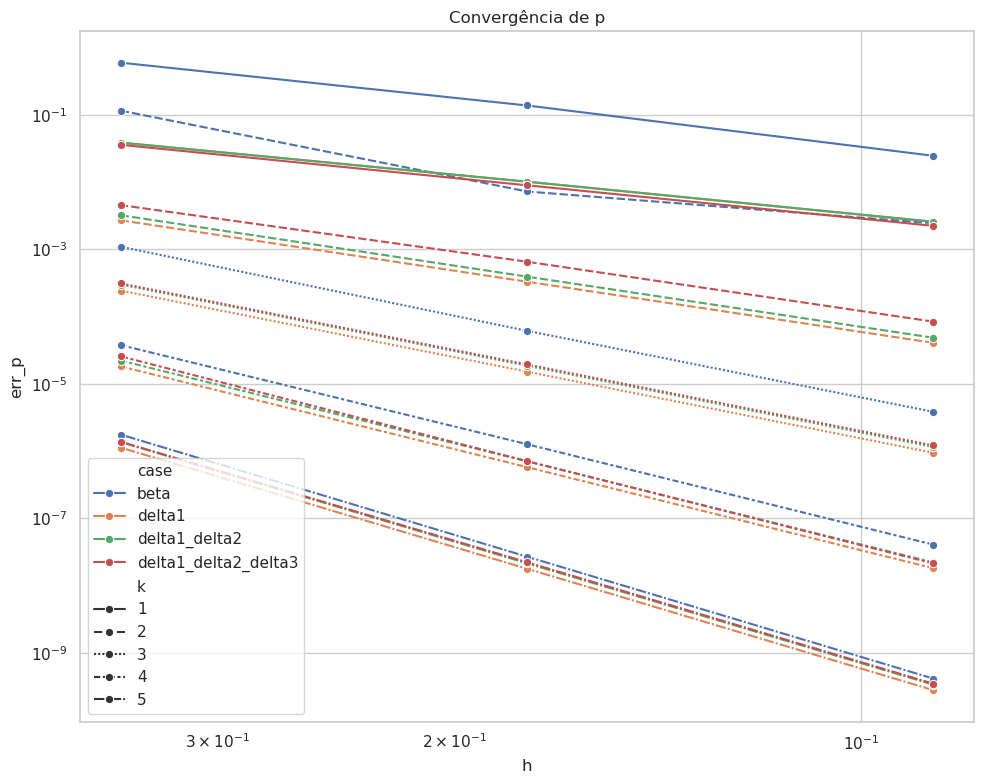

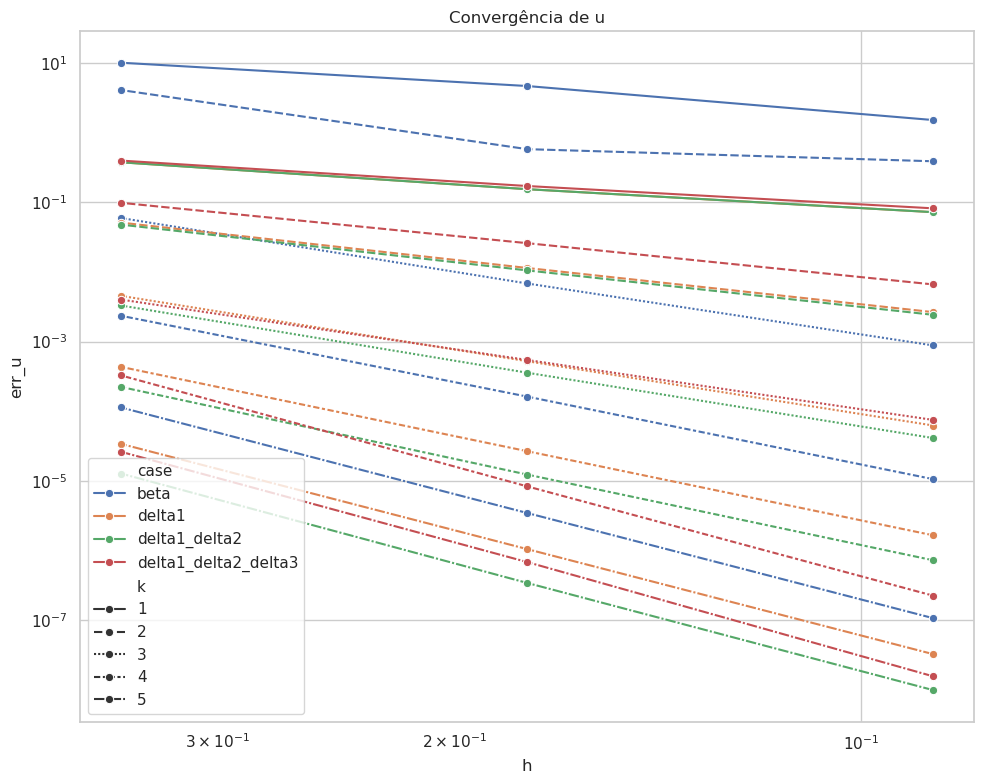

In [40]:
def plot_convergence(tab, error_col="err_p", title=None):
    plt.figure(figsize=(10, 8))

    ax = sns.lineplot(
        data=tab,
        x="h",
        y=error_col,
        hue="case",
        style="k",
        marker="o"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("h")
    ax.set_ylabel(error_col)
    ax.set_title(title if title is not None else error_col)

    plt.tight_layout()
    plt.savefig("hybridMixedFEM_2D/convergence_"+error_col+title+".pdf")
    plt.show()


plot_convergence(tab_all, error_col="err_p", title="Convergência de p")
plot_convergence(tab_all, error_col="err_u", title="Convergência de u")

In [27]:
def solve_primal_poisson_for_lambda(msh, degree=2, kind=SOL_KIND):
    if LinearProblem is None:
        raise RuntimeError("Não consegui importar dolfinx.fem.petsc.LinearProblem.")

    V = fem.functionspace(msh, ("Lagrange", degree))

    p = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    a = ufl.inner(ufl.grad(p), ufl.grad(v)) * ufl.dx
    L = f_ufl(msh, kind=kind) * v * ufl.dx

    pD = fem.Function(V)
    pD.interpolate(lambda x: p_exact_dolfinx(x, kind=kind))

    fdim = msh.topology.dim - 1
    bfacets = boundary_facets(msh)
    bdofs = fem.locate_dofs_topological(V, fdim, bfacets)

    bc = fem.dirichletbc(pD, bdofs)

    # Algumas versões novas do FEniCSx exigem petsc_options_prefix.
    try:
        problem = LinearProblem(
            a,
            L,
            bcs=[bc],
            petsc_options={
                "ksp_type": "preonly",
                "pc_type": "lu"
            },
            petsc_options_prefix="primal_poisson_"
        )
    except TypeError:
        # Compatibilidade com versões antigas
        problem = LinearProblem(
            a,
            L,
            bcs=[bc],
            petsc_options={
                "ksp_type": "preonly",
                "pc_type": "lu"
            }
        )

    ph = problem.solve()
    return ph

def lambda_coeffs_from_primal_function(msh, ph, k):
    coords, cell_vertices, cell_facets, facet_vertices, facet_cells, num_cells, num_facets = get_mesh_data(msh)

    ref = reference_data(k)
    edge_points = ref["edge_points"]
    n_edge = ref["n_edge"]

    lam = np.zeros(num_facets * n_edge)

    for f in range(num_facets):
        vids = facet_vertices.links(f)

        v0 = min(vids)
        v1 = max(vids)

        p0 = coords[v0]
        p1 = coords[v1]

        points_2d = p0 + edge_points[:, None] * (p1 - p0)

        adjacent_cells = facet_cells.links(f)
        cell_id = adjacent_cells[0]

        cells_eval = np.full(n_edge, cell_id, dtype=np.int32)

        points_3d = np.zeros((n_edge, 3))
        points_3d[:, :2] = points_2d

        try:
            values = ph.eval(points_3d, cells_eval).reshape(-1)
        except Exception:
            values = ph.eval(points_2d, cells_eval).reshape(-1)

        lam[f * n_edge:(f + 1) * n_edge] = values

    return lam


def solve_known_lambda_from_primal_2d(
    N,
    k,
    degree_primal=None,
    delta1=-0.5,
    delta2=0.5,
    delta3=0.0,
    kind=SOL_KIND
):
    if degree_primal is None:
        degree_primal = k + 1

    msh = create_square_mesh(N)

    ph_primal = solve_primal_poisson_for_lambda(
        msh,
        degree=degree_primal,
        kind=kind
    )

    lam_primal = lambda_coeffs_from_primal_function(
        msh,
        ph_primal,
        k=k
    )

    result = solve_known_lambda_2d(
        msh=msh,
        k=k,
        beta0=0.0,
        beta_scale="constant",
        delta1=delta1,
        delta2=delta2,
        delta3=delta3,
        kind=kind,
        lambda_coeffs=lam_primal
    )

    result["ph_primal"] = ph_primal
    result["solver"] = "known_lambda_from_primal"

    return result

In [29]:
N = 8
k = 1

res_primal_lambda = solve_known_lambda_from_primal_2d(
    N=N,
    k=k,
    degree_primal=k + 1,
    delta1=-0.5,
    delta2=0.5,
    delta3=0.0,
    kind=SOL_KIND
)

err_u, err_p = compute_L2_errors(res_primal_lambda)
err_lam = compute_lambda_skeleton_error(res_primal_lambda)

print("λ aproximado pelo problema primal")
print(f"N = {N}, k = {k}")
print(f"h       = {res_primal_lambda['h']:.4e}")
print(f"erro u  = {err_u:.4e}")
print(f"erro p  = {err_p:.4e}")
print(f"erro λ  = {err_lam:.4e}")
print(f"cond max= {res_primal_lambda['cond_max']:.4e}")

λ aproximado pelo problema primal
N = 8, k = 1
h       = 1.7678e-01
erro u  = 3.9864e-01
erro p  = 1.4200e-02
erro λ  = 7.2794e-02
cond max= 3.0889e+03


In [30]:
def convergence_table_primal_lambda_2d(
    N_list,
    k_list,
    case_name="lambda_primal_delta1_delta2",
    degree_primal_offset=1,
    delta1=-0.5,
    delta2=0.5,
    delta3=0.0,
    kind=SOL_KIND
):
    rows = []

    for k in k_list:
        previous_h = None
        previous_err_u = None
        previous_err_p = None
        previous_err_lam = None

        for N in N_list:
            start = time.time()

            result = solve_known_lambda_from_primal_2d(
                N=N,
                k=k,
                degree_primal=k + degree_primal_offset,
                delta1=delta1,
                delta2=delta2,
                delta3=delta3,
                kind=kind
            )

            err_u, err_p = compute_L2_errors(result)
            err_lam = compute_lambda_skeleton_error(result)

            elapsed = time.time() - start
            h = result["h"]

            if previous_h is None:
                rate_u = np.nan
                rate_p = np.nan
                rate_lam = np.nan
            else:
                rate_u = np.log(previous_err_u / err_u) / np.log(previous_h / h)
                rate_p = np.log(previous_err_p / err_p) / np.log(previous_h / h)

                if previous_err_lam > 0 and err_lam > 0:
                    rate_lam = np.log(previous_err_lam / err_lam) / np.log(previous_h / h)
                else:
                    rate_lam = np.nan

            rows.append({
                "case": case_name,
                "solver": "known_lambda_from_primal",
                "N": N,
                "k": k,
                "degree_primal": k + degree_primal_offset,
                "h": h,
                "beta_max": result["beta_max"],
                "delta1": delta1,
                "delta2": delta2,
                "delta3": delta3,
                "err_u": err_u,
                "rate_u": rate_u,
                "err_p": err_p,
                "rate_p": rate_p,
                "err_lambda": err_lam,
                "rate_lambda": rate_lam,
                "time_s": elapsed,
                "cond_local_max": result["cond_max"]
            })

            previous_h = h
            previous_err_u = err_u
            previous_err_p = err_p
            previous_err_lam = err_lam

            print(
                f"{case_name:28s} | N={N:3d} | k={k} | "
                f"err_u={err_u:.3e} | err_p={err_p:.3e} | "
                f"err_lam={err_lam:.3e} | time={elapsed:.2f}s"
            )

    return pd.DataFrame(rows)

In [31]:
tab_primal_lambda = convergence_table_primal_lambda_2d(
    N_list=[4, 8, 16],
    k_list=[1, 2, 3, 4, 5],
    case_name="lambda_primal_delta1_delta2",
    degree_primal_offset=1,
    delta1=-0.5,
    delta2=0.5,
    delta3=0.0,
    kind=SOL_KIND
)

tab_primal_lambda

lambda_primal_delta1_delta2  | N=  4 | k=1 | err_u=7.994e-01 | err_p=5.438e-02 | err_lam=2.015e-01 | time=0.02s
lambda_primal_delta1_delta2  | N=  8 | k=1 | err_u=3.986e-01 | err_p=1.420e-02 | err_lam=7.279e-02 | time=0.06s
lambda_primal_delta1_delta2  | N= 16 | k=1 | err_u=1.991e-01 | err_p=3.597e-03 | err_lam=2.581e-02 | time=0.24s
lambda_primal_delta1_delta2  | N=  4 | k=2 | err_u=1.197e-01 | err_p=4.270e-03 | err_lam=1.891e-02 | time=0.37s
lambda_primal_delta1_delta2  | N=  8 | k=2 | err_u=3.029e-02 | err_p=5.442e-04 | err_lam=3.391e-03 | time=0.07s
lambda_primal_delta1_delta2  | N= 16 | k=2 | err_u=7.586e-03 | err_p=6.826e-05 | err_lam=5.997e-04 | time=0.26s
lambda_primal_delta1_delta2  | N=  4 | k=3 | err_u=1.294e-02 | err_p=3.114e-04 | err_lam=1.594e-03 | time=0.37s
lambda_primal_delta1_delta2  | N=  8 | k=3 | err_u=1.642e-03 | err_p=1.990e-05 | err_lam=1.442e-04 | time=0.07s
lambda_primal_delta1_delta2  | N= 16 | k=3 | err_u=2.061e-04 | err_p=1.252e-06 | err_lam=1.282e-05 | tim

,case,solver,N,k,degree_primal,h,beta_max,delta1,delta2,delta3,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,time_s,cond_local_max
0,lambda_primal_delta1_delta2,known_lambda_from_primal,4,1,2,0.353553,0.0,-0.5,0.5,0.0,7.993525e-01,NaN,5.437726e-02,NaN,2.015348e-01,NaN,0.020036,7.846603e+02
1,lambda_primal_delta1_delta2,known_lambda_from_primal,8,1,2,0.176777,0.0,-0.5,0.5,0.0,3.986385e-01,1.003751,1.420048e-02,1.937063,7.279440e-02,1.469130,0.060436,3.088912e+03
2,lambda_primal_delta1_delta2,known_lambda_from_primal,16,1,2,0.088388,0.0,-0.5,0.5,0.0,1.991489e-01,1.001234,3.596973e-03,1.981085,2.580859e-02,1.495976,0.244988,1.230498e+04
3,lambda_primal_delta1_delta2,known_lambda_from_primal,4,2,3,0.353553,0.0,-0.5,0.5,0.0,1.197294e-01,NaN,4.270053e-03,NaN,1.890982e-02,NaN,0.368837,6.715525e+03
4,lambda_primal_delta1_delta2,known_lambda_from_primal,8,2,3,0.176777,0.0,-0.5,0.5,0.0,3.028706e-02,1.983004,5.442055e-04,2.972031,3.390576e-03,2.479533,0.069119,2.676406e+04
5,lambda_primal_delta1_delta2,known_lambda_from_primal,16,2,3,0.088388,0.0,-0.5,0.5,0.0,7.586172e-03,1.997257,6.825870e-05,2.995067,5.996696e-04,2.499291,0.258285,1.069580e+05
6,lambda_primal_delta1_delta2,known_lambda_from_primal,4,3,4,0.353553,0.0,-0.5,0.5,0.0,1.293898e-02,NaN,3.114437e-04,NaN,1.594492e-03,NaN,0.371835,3.529933e+04
7,lambda_primal_delta1_delta2,known_lambda_from_primal,8,3,4,0.176777,0.0,-0.5,0.5,0.0,1.642353e-03,2.977887,1.990217e-05,3.967974,1.441973e-04,3.466981,0.071977,1.411845e+05
8,lambda_primal_delta1_delta2,known_lambda_from_primal,16,3,4,0.088388,0.0,-0.5,0.5,0.0,2.061092e-04,2.994283,1.251667e-06,3.991003,1.282494e-05,3.491020,0.268401,5.647254e+05
9,lambda_primal_delta1_delta2,known_lambda_from_primal,4,4,5,0.353553,0.0,-0.5,0.5,0.0,1.161977e-03,NaN,2.069886e-05,NaN,1.234942e-04,NaN,0.366397,1.416542e+05


In [32]:
tab_primal_lambda_rot = convergence_table_primal_lambda_2d(
    N_list=[4, 8, 16],
    k_list=[1, 2, 3, 4, 5],
    case_name="lambda_primal_delta1_delta2_delta3",
    degree_primal_offset=1,
    delta1=-0.5,
    delta2=0.5,
    delta3=0.5,
    kind=SOL_KIND
)

tab_primal_lambda_rot

lambda_primal_delta1_delta2_delta3 | N=  4 | k=1 | err_u=7.994e-01 | err_p=5.438e-02 | err_lam=2.015e-01 | time=0.02s
lambda_primal_delta1_delta2_delta3 | N=  8 | k=1 | err_u=3.986e-01 | err_p=1.420e-02 | err_lam=7.279e-02 | time=0.07s
lambda_primal_delta1_delta2_delta3 | N= 16 | k=1 | err_u=1.991e-01 | err_p=3.597e-03 | err_lam=2.581e-02 | time=0.25s
lambda_primal_delta1_delta2_delta3 | N=  4 | k=2 | err_u=1.179e-01 | err_p=4.269e-03 | err_lam=1.891e-02 | time=0.02s
lambda_primal_delta1_delta2_delta3 | N=  8 | k=2 | err_u=2.976e-02 | err_p=5.442e-04 | err_lam=3.391e-03 | time=0.07s
lambda_primal_delta1_delta2_delta3 | N= 16 | k=2 | err_u=7.452e-03 | err_p=6.826e-05 | err_lam=5.997e-04 | time=0.27s
lambda_primal_delta1_delta2_delta3 | N=  4 | k=3 | err_u=1.226e-02 | err_p=3.107e-04 | err_lam=1.594e-03 | time=0.02s
lambda_primal_delta1_delta2_delta3 | N=  8 | k=3 | err_u=1.552e-03 | err_p=1.985e-05 | err_lam=1.442e-04 | time=0.07s
lambda_primal_delta1_delta2_delta3 | N= 16 | k=3 | err_u

,case,solver,N,k,degree_primal,h,beta_max,delta1,delta2,delta3,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,time_s,cond_local_max
0,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,4,1,2,0.353553,0.0,-0.5,0.5,0.5,7.993525e-01,NaN,5.437726e-02,NaN,2.015348e-01,NaN,0.021552,7.846603e+02
1,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,8,1,2,0.176777,0.0,-0.5,0.5,0.5,3.986385e-01,1.003751,1.420048e-02,1.937063,7.279440e-02,1.469130,0.067051,3.088912e+03
2,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,16,1,2,0.088388,0.0,-0.5,0.5,0.5,1.991489e-01,1.001234,3.596973e-03,1.981085,2.580859e-02,1.495976,0.252898,1.230498e+04
3,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,4,2,3,0.353553,0.0,-0.5,0.5,0.5,1.178543e-01,NaN,4.269351e-03,NaN,1.890982e-02,NaN,0.022239,5.415160e+03
4,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,8,2,3,0.176777,0.0,-0.5,0.5,0.5,2.976393e-02,1.985368,5.441918e-04,2.971830,3.390576e-03,2.479533,0.070099,2.160348e+04
5,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,16,2,3,0.088388,0.0,-0.5,0.5,0.5,7.451854e-03,1.997894,6.825921e-05,2.995020,5.996696e-04,2.499291,0.271577,8.635682e+04
6,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,4,3,4,0.353553,0.0,-0.5,0.5,0.5,1.225633e-02,NaN,3.107168e-04,NaN,1.594492e-03,NaN,0.022445,1.913631e+04
7,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,8,3,4,0.176777,0.0,-0.5,0.5,0.5,1.552324e-03,2.981025,1.985256e-05,3.968203,1.441973e-04,3.466981,0.073888,7.648417e+04
8,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,16,3,4,0.088388,0.0,-0.5,0.5,0.5,1.946943e-04,2.995147,1.248468e-06,3.991094,1.282494e-05,3.491020,0.292862,3.058756e+05
9,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,4,4,5,0.353553,0.0,-0.5,0.5,0.5,1.039573e-03,NaN,2.058764e-05,NaN,1.234942e-04,NaN,0.026360,5.464799e+04


In [33]:
tab_all_final = pd.concat(
    [
        tab_all,
        tab_primal_lambda,
        tab_primal_lambda_rot,  
    ],
    ignore_index=True
)

tab_all_final

,case,solver,N,k,h,beta_max,delta1,delta2,delta3,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,time_s,cond_local_max,degree_primal
0,beta,hybrid,4,1,0.353553,28.284271,0.0,0.0,0.0,1.013183e+01,NaN,5.930209e-01,NaN,1.237370e+00,NaN,0.018939,3.499274e+05,NaN
1,beta,hybrid,8,1,0.176777,56.568542,0.0,0.0,0.0,4.685846e+00,1.112513,1.371227e-01,2.112616,4.140369e-01,1.579445,0.058225,1.399033e+06,NaN
2,beta,hybrid,16,1,0.088388,113.137085,0.0,0.0,0.0,1.519742e+00,1.624483,2.448309e-02,2.485610,9.448470e-02,2.131607,0.226903,5.595453e+06,NaN
3,beta,hybrid,4,2,0.353553,113.137085,0.0,0.0,0.0,4.103093e+00,NaN,1.147927e-01,NaN,3.382052e-01,NaN,0.016705,1.899310e+05,NaN
4,beta,hybrid,8,2,0.176777,226.274170,0.0,0.0,0.0,5.805696e-01,2.821171,7.212991e-03,3.992289,3.260515e-02,3.374727,0.062255,7.595505e+05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,8,4,0.176777,0.000000,-0.5,0.5,0.5,6.570356e-05,3.983875,6.530646e-07,4.978409,5.543286e-06,4.477558,0.085059,2.184830e+05,5.0
86,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,16,4,0.088388,0.000000,-0.5,0.5,0.5,4.115363e-06,3.996880,2.047862e-08,4.995035,2.457886e-07,4.495252,0.326156,8.738232e+05,5.0
87,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,4,5,0.353553,0.000000,-0.5,0.5,0.5,8.017473e-05,NaN,1.239760e-06,NaN,8.516693e-06,NaN,0.028303,1.559242e+05,6.0
88,lambda_primal_delta1_delta2_delta3,known_lambda_from_primal,8,5,0.176777,0.000000,-0.5,0.5,0.5,2.540690e-06,4.979855,1.965389e-08,5.979102,1.913107e-07,5.476304,0.098517,6.234540e+05,6.0


In [34]:
def compact_final_table(tab):
    rows = []

    for case in tab["case"].unique():
        tab_case = tab[tab["case"] == case]

        for k in sorted(tab_case["k"].unique()):
            sub = tab_case[tab_case["k"] == k].sort_values("N")
            last = sub.iloc[-1]

            rows.append({
                "case": case,
                "k": int(k),
                "N_final": int(last["N"]),
                "h": last["h"],
                "err_u": last["err_u"],
                "rate_u": last["rate_u"],
                "err_p": last["err_p"],
                "rate_p": last["rate_p"],
                "err_lambda": last["err_lambda"],
                "rate_lambda": last["rate_lambda"],
                "cond_local_max": last["cond_local_max"],
            })

    return pd.DataFrame(rows)


tab_compact = compact_final_table(tab_all_final)
tab_compact

,case,k,N_final,h,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,cond_local_max
0,beta,1,16,0.088388,1.519742e+00,1.624483,2.448309e-02,2.485610,9.448470e-02,2.131607,5.595453e+06
1,beta,2,16,0.088388,3.887440e-01,0.578649,2.428803e-03,1.570352,1.641932e-02,0.989705,3.038028e+06
2,beta,3,16,0.088388,8.785905e-04,2.958390,3.817722e-06,4.001625,3.571719e-05,3.507412,2.902383e+06
3,beta,4,16,0.088388,1.053307e-05,3.941751,4.047264e-08,4.959554,5.474594e-07,4.425022,1.072918e+07
4,beta,5,16,0.088388,1.060213e-07,5.022138,4.125238e-10,6.020209,4.359829e-09,5.554018,3.735701e+07
5,delta1,1,16,0.088388,7.216833e-02,1.097704,2.558167e-03,1.979370,1.758475e-02,1.514916,9.219997e+03
6,delta1,2,16,0.088388,2.643844e-03,2.108498,4.053945e-05,3.017789,3.517944e-04,2.529874,1.078665e+05
7,delta1,3,16,0.088388,6.215345e-05,3.069721,9.382077e-07,4.007591,8.751979e-06,3.505975,5.773121e+05
8,delta1,4,16,0.088388,1.644483e-06,4.015515,1.803584e-08,4.992917,1.731203e-07,4.495560,2.316724e+06
9,delta1,5,16,0.088388,3.225437e-08,5.015106,2.775196e-10,5.996496,2.821358e-09,5.499084,8.202426e+06


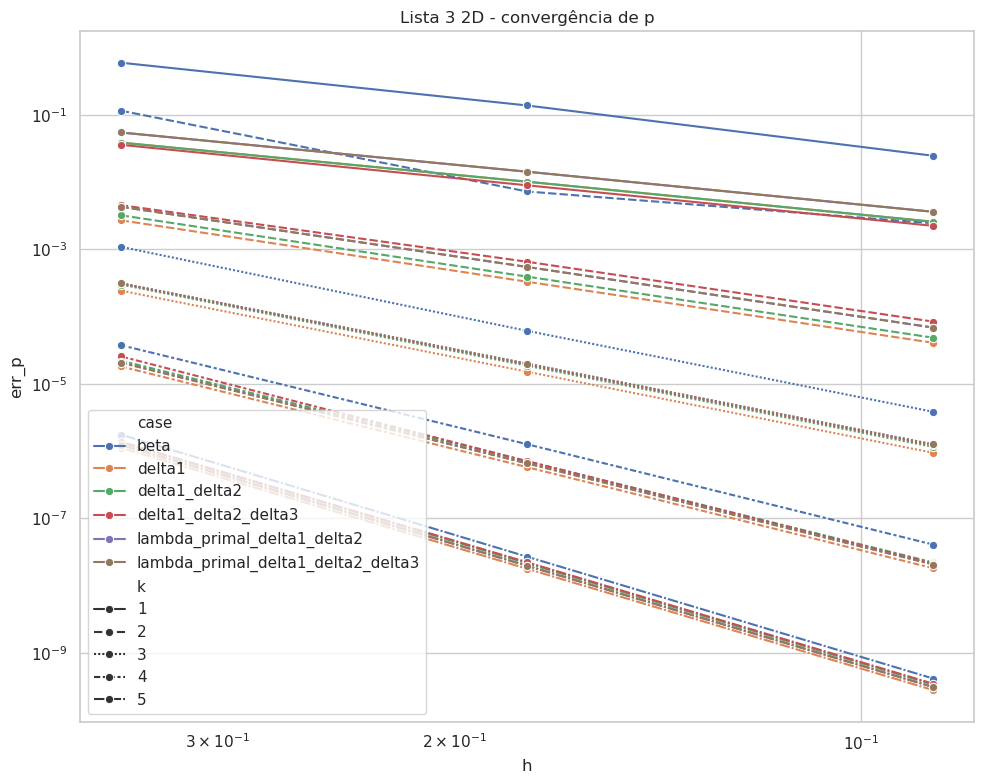

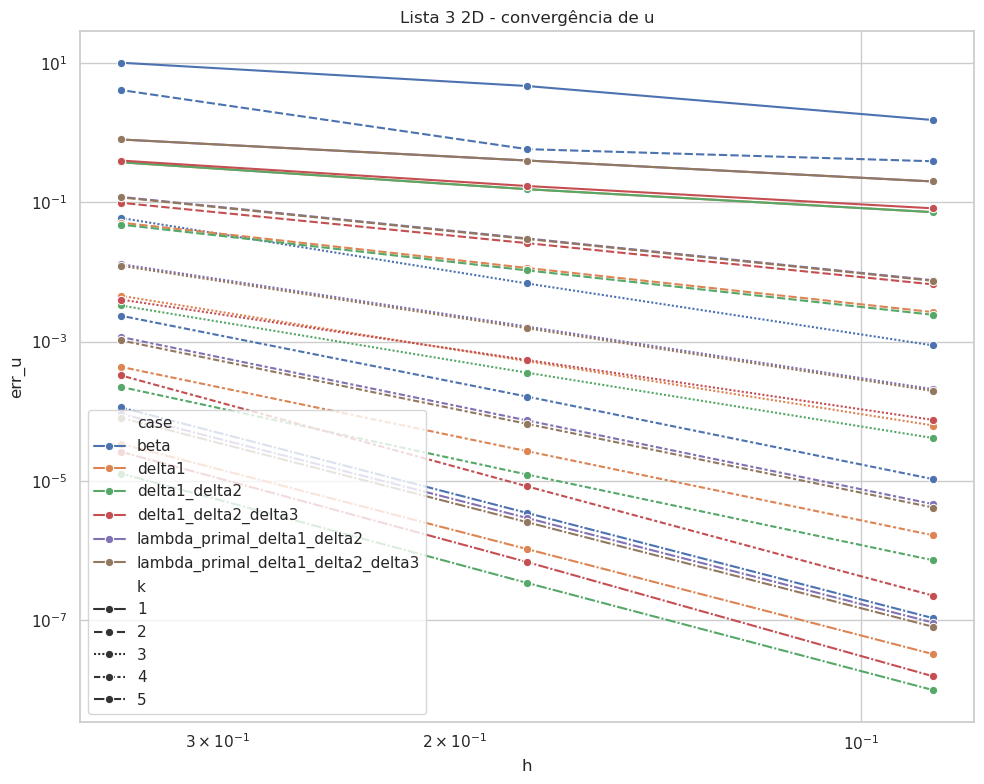

In [41]:
plot_convergence(
    tab_all_final,
    error_col="err_p",
    title="Lista 3 2D - convergência de p"
)

plot_convergence(
    tab_all_final,
    error_col="err_u",
    title="Lista 3 2D - convergência de u"
)

In [42]:
def show_case_table(tab, case):
    cols = [
        "N", "k", "h",
        "err_u", "rate_u",
        "err_p", "rate_p",
        "err_lambda", "rate_lambda",
        "cond_local_max"
    ]

    sub = tab[tab["case"] == case][cols].copy()
    display(sub)

    filename = f"lista3_2d_{case}.csv"
    sub.to_csv(filename, index=False)

    print(f"Salvo em: {filename}")


for case in tab_all_final["case"].unique():
    print("\n" + "=" * 80)
    print(case)
    show_case_table(tab_all_final, case)


beta


,N,k,h,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,cond_local_max
0,4,1,0.353553,1.013183e+01,NaN,5.930209e-01,NaN,1.237370e+00,NaN,3.499274e+05
1,8,1,0.176777,4.685846e+00,1.112513,1.371227e-01,2.112616,4.140369e-01,1.579445,1.399033e+06
2,16,1,0.088388,1.519742e+00,1.624483,2.448309e-02,2.485610,9.448470e-02,2.131607,5.595453e+06
3,4,2,0.353553,4.103093e+00,NaN,1.147927e-01,NaN,3.382052e-01,NaN,1.899310e+05
4,8,2,0.176777,5.805696e-01,2.821171,7.212991e-03,3.992289,3.260515e-02,3.374727,7.595505e+05
5,16,2,0.088388,3.887440e-01,0.578649,2.428803e-03,1.570352,1.641932e-02,0.989705,3.038028e+06
6,4,3,0.353553,5.950940e-02,NaN,1.085826e-03,NaN,5.539665e-03,NaN,1.814011e+05
7,8,3,0.176777,6.828897e-03,3.123393,6.115238e-05,4.150240,4.061754e-04,3.769624,7.255974e+05
8,16,3,0.088388,8.785905e-04,2.958390,3.817722e-06,4.001625,3.571719e-05,3.507412,2.902383e+06
9,4,4,0.353553,2.346989e-03,NaN,3.743895e-05,NaN,2.316561e-04,NaN,6.705760e+05


Salvo em: lista3_2d_beta.csv

delta1


,N,k,h,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,cond_local_max
15,4,1,0.353553,3.759688e-01,NaN,3.845425e-02,NaN,1.433439e-01,NaN,5.799456e+02
16,8,1,0.176777,1.544502e-01,1.283472,1.008738e-02,1.930591,5.025408e-02,1.512168,2.307986e+03
17,16,1,0.088388,7.216833e-02,1.097704,2.558167e-03,1.979370,1.758475e-02,1.514916,9.219997e+03
18,4,2,0.353553,5.111748e-02,NaN,2.690549e-03,NaN,1.186886e-02,NaN,6.750092e+03
19,8,2,0.176777,1.140137e-02,2.164610,3.283392e-04,3.034641,2.031687e-03,2.546431,2.697338e+04
20,16,2,0.088388,2.643844e-03,2.108498,4.053945e-05,3.017789,3.517944e-04,2.529874,1.078665e+05
21,4,3,0.353553,4.536159e-03,NaN,2.421215e-04,NaN,1.120308e-03,NaN,3.608520e+04
22,8,3,0.176777,5.218474e-04,3.119772,1.509052e-05,4.004017,9.942828e-05,3.494096,1.443306e+05
23,16,3,0.088388,6.215345e-05,3.069721,9.382077e-07,4.007591,8.751979e-06,3.505975,5.773121e+05
24,4,4,0.353553,4.327822e-04,NaN,1.805745e-05,NaN,8.711422e-05,NaN,1.448020e+05


Salvo em: lista3_2d_delta1.csv

delta1_delta2


...

Salvo em: lista3_2d_delta1_delta2_delta3.csv

lambda_primal_delta1_delta2


,N,k,h,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,cond_local_max
60,4,1,0.353553,7.993525e-01,NaN,5.437726e-02,NaN,2.015348e-01,NaN,7.846603e+02
61,8,1,0.176777,3.986385e-01,1.003751,1.420048e-02,1.937063,7.279440e-02,1.469130,3.088912e+03
62,16,1,0.088388,1.991489e-01,1.001234,3.596973e-03,1.981085,2.580859e-02,1.495976,1.230498e+04
63,4,2,0.353553,1.197294e-01,NaN,4.270053e-03,NaN,1.890982e-02,NaN,6.715525e+03
64,8,2,0.176777,3.028706e-02,1.983004,5.442055e-04,2.972031,3.390576e-03,2.479533,2.676406e+04
65,16,2,0.088388,7.586172e-03,1.997257,6.825870e-05,2.995067,5.996696e-04,2.499291,1.069580e+05
66,4,3,0.353553,1.293898e-02,NaN,3.114437e-04,NaN,1.594492e-03,NaN,3.529933e+04
67,8,3,0.176777,1.642353e-03,2.977887,1.990217e-05,3.967974,1.441973e-04,3.466981,1.411845e+05
68,16,3,0.088388,2.061092e-04,2.994283,1.251667e-06,3.991003,1.282494e-05,3.491020,5.647254e+05
69,4,4,0.353553,1.161977e-03,NaN,2.069886e-05,NaN,1.234942e-04,NaN,1.416542e+05


Salvo em: lista3_2d_lambda_primal_delta1_delta2.csv

lambda_primal_delta1_delta2_delta3


,N,k,h,err_u,rate_u,err_p,rate_p,err_lambda,rate_lambda,cond_local_max
75,4,1,0.353553,7.993525e-01,NaN,5.437726e-02,NaN,2.015348e-01,NaN,7.846603e+02
76,8,1,0.176777,3.986385e-01,1.003751,1.420048e-02,1.937063,7.279440e-02,1.469130,3.088912e+03
77,16,1,0.088388,1.991489e-01,1.001234,3.596973e-03,1.981085,2.580859e-02,1.495976,1.230498e+04
78,4,2,0.353553,1.178543e-01,NaN,4.269351e-03,NaN,1.890982e-02,NaN,5.415160e+03
79,8,2,0.176777,2.976393e-02,1.985368,5.441918e-04,2.971830,3.390576e-03,2.479533,2.160348e+04
80,16,2,0.088388,7.451854e-03,1.997894,6.825921e-05,2.995020,5.996696e-04,2.499291,8.635682e+04
81,4,3,0.353553,1.225633e-02,NaN,3.107168e-04,NaN,1.594492e-03,NaN,1.913631e+04
82,8,3,0.176777,1.552324e-03,2.981025,1.985256e-05,3.968203,1.441973e-04,3.466981,7.648417e+04
83,16,3,0.088388,1.946943e-04,2.995147,1.248468e-06,3.991094,1.282494e-05,3.491020,3.058756e+05
84,4,4,0.353553,1.039573e-03,NaN,2.058764e-05,NaN,1.234942e-04,NaN,5.464799e+04


Salvo em: lista3_2d_lambda_primal_delta1_delta2_delta3.csv


In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import griddata

sns.set_theme(style="white")


def plot_field_clean(
    df,
    value,
    title=None,
    cbar_label=None,
    nx=200,
    ny=200,
    cmap="viridis",
    figsize=(8, 6)
):
    x = df["x"].to_numpy()
    y = df["y"].to_numpy()
    z = df[value].to_numpy()

    xi = np.linspace(x.min(), x.max(), nx)
    yi = np.linspace(y.min(), y.max(), ny)
    X, Y = np.meshgrid(xi, yi)

    Z = griddata((x, y), z, (X, Y), method="linear")

    fig, ax = plt.subplots(figsize=figsize)

    pcm = ax.pcolormesh(
        X, Y, Z,
        shading="auto",
        cmap=cmap
    )

    cbar = fig.colorbar(pcm, ax=ax)
    if cbar_label is None:
        cbar_label = value
    cbar.set_label(cbar_label)

    ax.set_title(title if title is not None else value, fontsize=16)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

    ax.grid(False)
    sns.despine(ax=ax, left=False, bottom=False)

    plt.tight_layout()
    plt.savefig("hybridMixedFEM_2D/"+title+".pdf")
    plt.show()

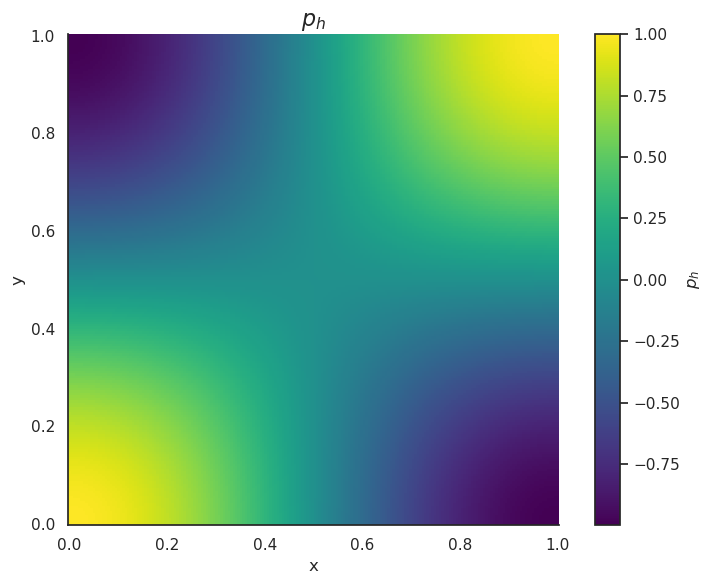

In [46]:
plot_field_clean(
    df_plot,
    value="p_h",
    title=r"$p_h$",
    cbar_label=r"$p_h$"
)

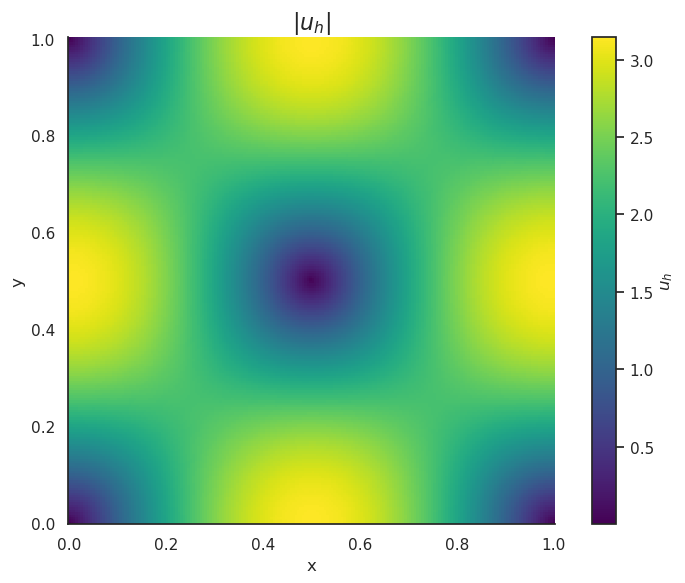

In [47]:
plot_field_clean(
    df_plot,
    value="u_norm_h",
    title=r"$|u_h|$",
    cbar_label=r"$u_h$"
)

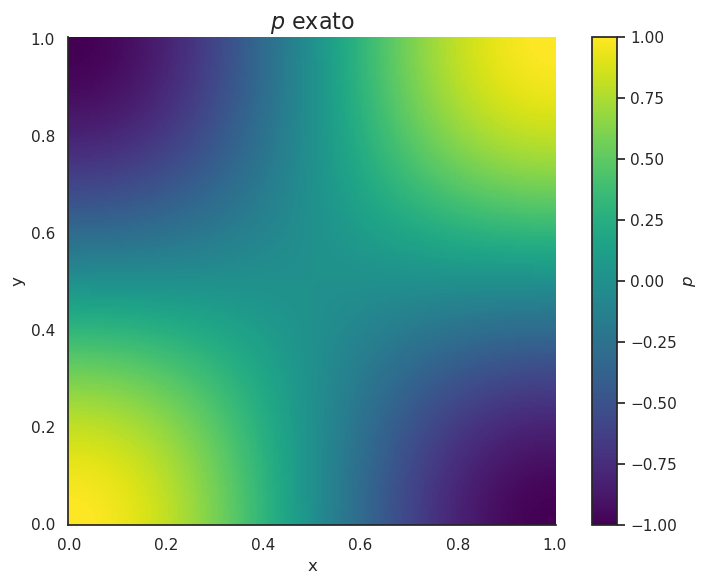

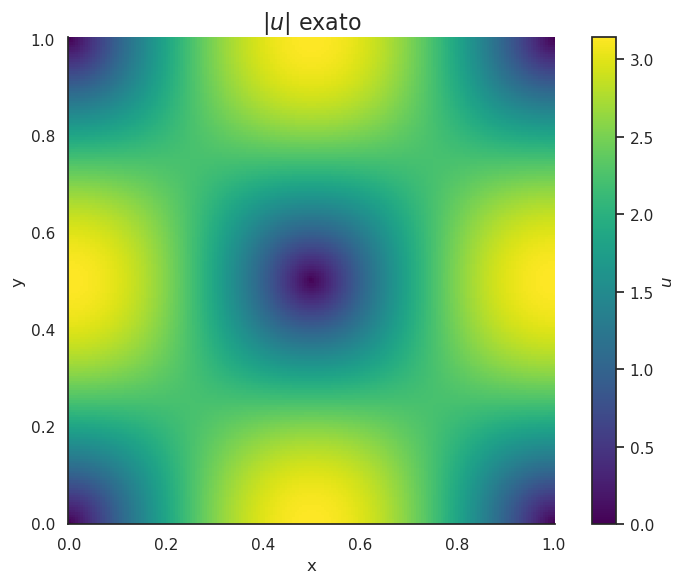

In [48]:
plot_field_clean(
    df_plot,
    value="p_exact",
    title=r"$p$ exato",
    cbar_label=r"$p$"
)

plot_field_clean(
    df_plot,
    value="u_norm_exact",
    title=r"$|u|$ exato",
    cbar_label=r"$u$"
)